### Overview of tokenization techniques
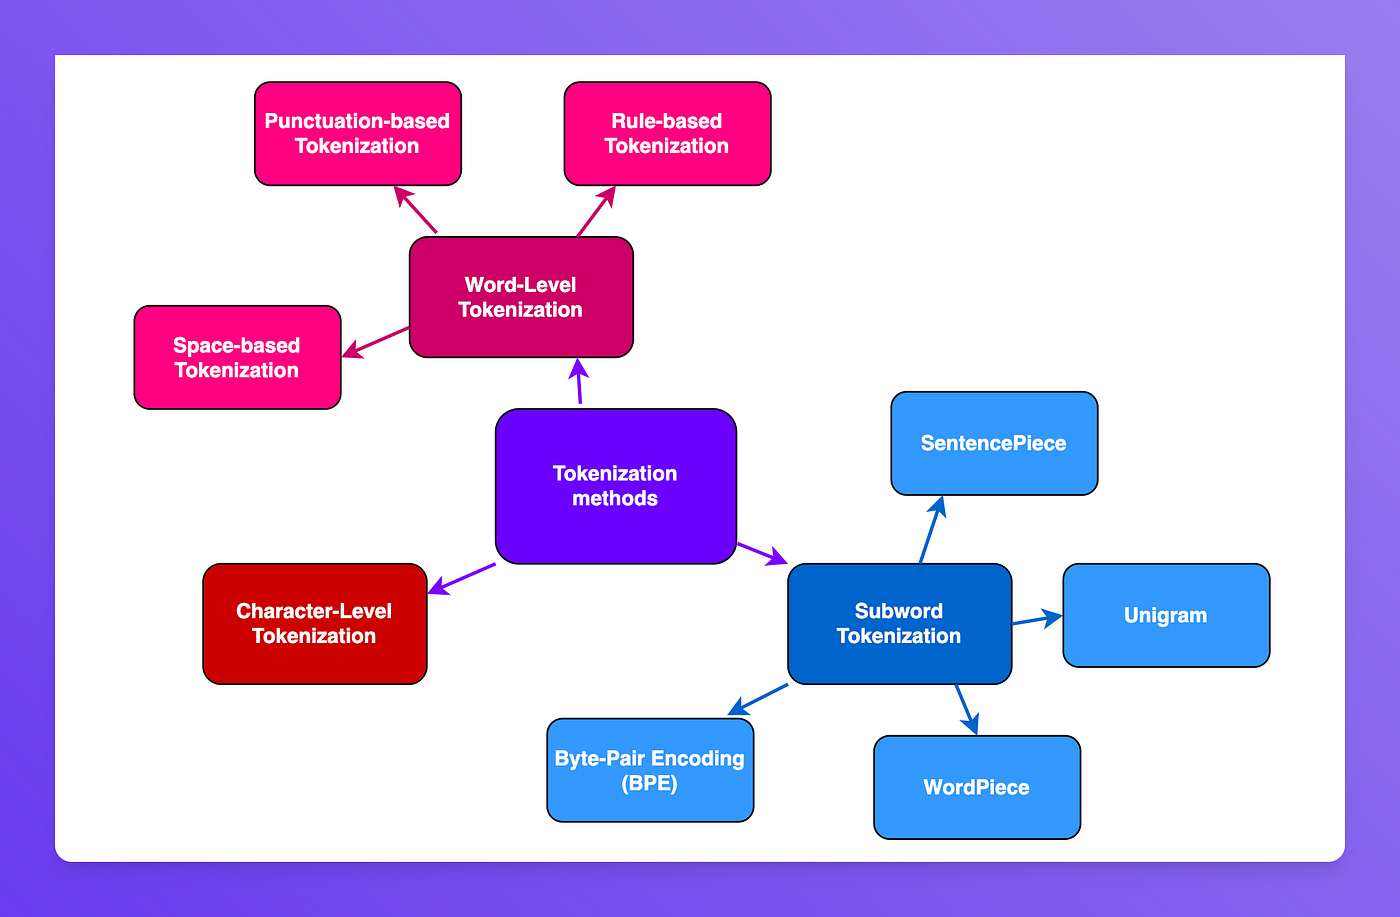

In [28]:
import torch
import torch.nn as nn
import json
from pathlib import Path
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.trainers import WordLevelTrainer
from tokenizers.pre_tokenizers import Whitespace

In [29]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # ensure deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### Test Tokenizer

In [30]:
# corpus = [
#     "i like cat",
#     "girl friend are expensive",
# ]

# tokenizer = Tokenizer(WordLevel())
# tokenizer.pre_tokenizer = Whitespace()
# vocab = {
#     "[UNK]": 0,
#     "hello": 1,
#     "world": 2,
# }
# sequence_length = 5

# #? add word to vocab
# for sentence in corpus:
#     for word in sentence.split(' '):
#         if word not in vocab.keys():
#             vocab[word] = len(vocab) + 1


# tokenizer = Tokenizer(WordLevel(vocab=vocab, unk_token="[UNK]"))
# tokenizer.pre_tokenizer = Whitespace()

# tokenize_samples = [tokenizer.encode(sample) for sample in corpus]
# print(tokenizer.get_vocab())
# print(tokenize_samples[0].tokens, '-', tokenize_samples[0].ids)
# print(len(vocab))

### POS Tagging Tokenizer

In [31]:
dataset_path = Path("POS_mockdataset.json")
if not dataset_path.exists():
    dataset_path = Path("_Research") / "POS_mockdataset.json"

with open(dataset_path, "r", encoding="utf-8") as file:
    dataset = json.load(file)

corpus = dataset["corpus"]
labels = dataset["labels"]

#? 0: noun/pronoun - 1: verb - others - 2
assert len(corpus) == len(labels)

#? Define the max vocabulary size and sequence length
vocab_size = len(corpus)
sequence_length = 4
print(vocab_size)

#? Initialize tokenizer by Corpus
tokenizer = Tokenizer(WordLevel())
tokenizer.pre_tokenizer = Whitespace()

30


In [32]:
tokenizer.enable_padding(pad_id=1,
                        pad_token="<pad>",
                        length=sequence_length)
tokenizer.enable_truncation(max_length=sequence_length)

# Choose type of Tokenizer Strategy
trainer = WordLevelTrainer(vocab_size=vocab_size,
                            special_tokens=['<unk>', '<pad>'])
# Apply Tokenizer to the Corpus
tokenizer.train_from_iterator(corpus, trainer=trainer)
print(tokenizer.model)

vocab = tokenizer.get_vocab()
print(vocab)

tokenize_samples = [tokenizer.encode(sample) for sample in corpus]
vocab_size = len(vocab)
print(tokenize_samples[0].tokens, '-', tokenize_samples[0].ids)
print(tokenize_samples[1].tokens, '-', tokenize_samples[1].ids)
print(len(vocab))

WordLevel(vocab={"<unk>":0, "<pad>":1, "the":2, "i":3, "we":4, ...}, unk_token="<unk>")
{'books': 6, 'birds': 21, 'they': 16, 'dogs': 7, 'chase': 29, 'build': 25, 'bark': 20, 'he': 10, 'good': 9, '<pad>': 1, 'ask': 18, 'brightly': 24, 'enjoy': 8, 'cats': 28, 'bright': 23, 'cat': 27, 'she': 15, 'we': 4, 'i': 3, 'always': 17, 'model': 12, 'in': 11, 'new': 14, 'calm': 26, 'boy': 22, 'at': 19, 'music': 13, '<unk>': 0, 'the': 2, 'a': 5}
['i', '<unk>', 'a', '<unk>'] - [3, 0, 5, 0]
['we', '<unk>', 'new', 'books'] - [4, 0, 14, 6]
30


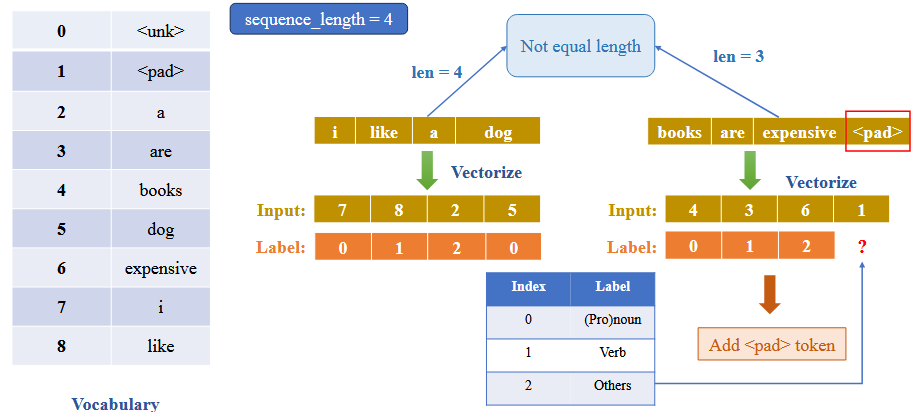
Note that Padding for Labels (POS) if different from Text

### Embedding

In [33]:
def vectorize_text(sentence, tokenizer):
    output = tokenizer.encode(sentence)
    return torch.tensor(output.ids, dtype=torch.long)

def vectorize_label(sentence_labels, sequence_length):
    #? add [3] as padding, for the number of missing label compare to sequence length
    sentence_labels = sentence_labels + [3]*(sequence_length - len(sentence_labels))
    return torch.tensor(sentence_labels, dtype=torch.long)

In [34]:
X = []
y = []

for sentence, sentence_labels in zip(corpus, labels):
    X.append(vectorize_text(sentence, tokenizer))
    y.append(vectorize_label(sentence_labels, sequence_length))

print(X)
print(y)

[tensor([3, 0, 5, 0]), tensor([ 4,  0, 14,  6]), tensor([16,  0, 11,  0]), tensor([15,  0,  0,  0]), tensor([28, 29,  0,  0]), tensor([21,  0, 11,  0]), tensor([10,  0,  0, 26]), tensor([3, 8, 0, 0]), tensor([7, 0, 2, 0]), tensor([ 0,  0, 23,  0]), tensor([ 0,  0,  0, 13]), tensor([ 2, 22,  0,  0]), tensor([5, 0, 0, 0]), tensor([0, 0, 0, 0]), tensor([ 2,  0,  0, 24]), tensor([16,  0,  0,  0]), tensor([6, 0, 0, 0]), tensor([4, 0, 0, 0]), tensor([0, 0, 0, 0]), tensor([2, 0, 0, 0]), tensor([10, 17,  0,  0]), tensor([ 9,  0, 18,  0]), tensor([ 0, 12,  0,  0]), tensor([ 0,  8,  9, 13]), tensor([ 2, 27,  0,  0]), tensor([3, 0, 0, 0]), tensor([ 0, 25, 14,  0]), tensor([15,  0,  0,  0]), tensor([ 4,  0,  2, 12]), tensor([ 7, 20, 19,  0])]
[tensor([0, 1, 2, 0]), tensor([0, 1, 2, 0]), tensor([0, 1, 2, 0]), tensor([0, 1, 2, 0]), tensor([0, 1, 2, 0]), tensor([0, 1, 2, 0]), tensor([0, 1, 2, 2]), tensor([0, 1, 2, 0]), tensor([0, 1, 2, 0]), tensor([0, 1, 2, 0]), tensor([0, 0, 1, 0]), tensor([2, 0, 1,

### Create the dataset

In [35]:
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split # type: ignore

class CustomTestDataset(Dataset):
    def __init__(self, features, labels) -> None:
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train)
print(y_train)
print(X_test)
print(y_test)

test_dataset = CustomTestDataset(X_test, y_test)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0 # auto choose CPU-cores
)

[tensor([ 4,  0,  2, 12]), tensor([ 2, 27,  0,  0]), tensor([5, 0, 0, 0]), tensor([3, 0, 5, 0]), tensor([28, 29,  0,  0]), tensor([6, 0, 0, 0]), tensor([21,  0, 11,  0]), tensor([0, 0, 0, 0]), tensor([ 2, 22,  0,  0]), tensor([ 0, 12,  0,  0]), tensor([ 4,  0, 14,  6]), tensor([16,  0, 11,  0]), tensor([3, 0, 0, 0]), tensor([15,  0,  0,  0]), tensor([ 9,  0, 18,  0]), tensor([ 0, 25, 14,  0]), tensor([0, 0, 0, 0]), tensor([ 7, 20, 19,  0]), tensor([10, 17,  0,  0]), tensor([3, 8, 0, 0]), tensor([ 0,  0,  0, 13]), tensor([ 2,  0,  0, 24]), tensor([2, 0, 0, 0]), tensor([10,  0,  0, 26])]
[tensor([0, 1, 2, 0]), tensor([2, 0, 1, 0]), tensor([2, 0, 1, 0]), tensor([0, 1, 2, 0]), tensor([0, 1, 2, 0]), tensor([0, 1, 2, 0]), tensor([0, 1, 2, 0]), tensor([0, 0, 1, 2]), tensor([2, 0, 1, 0]), tensor([2, 0, 1, 0]), tensor([0, 1, 2, 0]), tensor([0, 1, 2, 0]), tensor([0, 1, 2, 0]), tensor([0, 1, 2, 0]), tensor([2, 0, 1, 0]), tensor([0, 1, 2, 0]), tensor([0, 0, 1, 0]), tensor([0, 1, 2, 0]), tensor([0,

## Model

In [36]:
class POS_Model(nn.Module):
    def __init__(self, vocab_size, num_classes, d_model=4) -> None:
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.fc = nn.Linear(d_model, num_classes) # output must match number of class

    def forward(self, x):
        # x = x.unsqueeze(0) # add batch_dim
        # apply permute because nn.CrossEntropy input shape is (batch_sizeK, model_dim)
        x = self.embedding(x)
        x = self.fc(x) # (1, 4, 4) - batch, seq_len, dim
        print(x.shape)

        return x.permute(0, 2, 1)

# test_input = torch.tensor([[7, 8, 2, 5]], dtype=torch.long)
pos_model = POS_Model(vocab_size, 4)
out = pos_model(X[0].unsqueeze(0))
print(out.shape)
print(pos_model.embedding.weight.shape)

torch.Size([1, 4, 4])
torch.Size([1, 4, 4])
torch.Size([30, 4])


In [37]:
device = 'cuda' if torch.cuda.is_available() else 'cpu' # set to cuda
loss_func = nn.CrossEntropyLoss() # ignore_index=3
optimizer = torch.optim.Adam(pos_model.parameters(), lr=0.01)
epoch = 50

pos_model.train() # turn on training mode
# with torch.no_grad():
correct_predictions = 0
total_loss = 0
total_samples = 0

for inputs, labels in test_dataloader:
    # move data to CUDA
    # inputs, labels = inputs.to(device), labels.to(device)
    print(inputs.shape, labels)

    optimizer.zero_grad()

    # # Forward pass
    outputs = pos_model(inputs)
    loss = loss_func(outputs, labels)
    print(loss.item())
    # # total_loss += loss.items()

    loss.backward()
    optimizer.step()

torch.Size([1, 4]) tensor([[0, 1, 2, 0]])
torch.Size([1, 4, 4])
1.9349613189697266
torch.Size([1, 4]) tensor([[0, 2, 1, 0]])
torch.Size([1, 4, 4])
1.9535093307495117
torch.Size([1, 4]) tensor([[0, 1, 2, 0]])
torch.Size([1, 4, 4])
1.969555377960205
torch.Size([1, 4]) tensor([[0, 1, 2, 0]])
torch.Size([1, 4, 4])
1.7454135417938232
torch.Size([1, 4]) tensor([[0, 1, 2, 0]])
torch.Size([1, 4, 4])
1.433526873588562
torch.Size([1, 4]) tensor([[0, 1, 2, 0]])
torch.Size([1, 4, 4])
1.6270397901535034


In [38]:
outputs = pos_model(X[0].unsqueeze(0)) # "i like a dog" - [0,1,2,0]
o_softmax = torch.softmax(outputs, axis=1)
# print(o_softmax)
# o_sum = torch.sum(o_softmax, dim=1) # sum over column
# print(o_sum)

print(o_softmax[0, :, 0])
print(o_softmax[0, :, 1])
print(o_softmax[0, :, 2])
print(o_softmax[0, :, 3])

o_softmax.argmax(axis=1)
print(o_softmax)

torch.Size([1, 4, 4])
tensor([0.3351, 0.1188, 0.4099, 0.1363], grad_fn=<SelectBackward0>)
tensor([0.1209, 0.3341, 0.2567, 0.2883], grad_fn=<SelectBackward0>)
tensor([0.1398, 0.0536, 0.7591, 0.0475], grad_fn=<SelectBackward0>)
tensor([0.1209, 0.3341, 0.2567, 0.2883], grad_fn=<SelectBackward0>)
tensor([[[0.3351, 0.1209, 0.1398, 0.1209],
         [0.1188, 0.3341, 0.0536, 0.3341],
         [0.4099, 0.2567, 0.7591, 0.2567],
         [0.1363, 0.2883, 0.0475, 0.2883]]], grad_fn=<SoftmaxBackward0>)


### Test POS Prediction

Use this cell to check whether the trained model predicts the correct POS tags for a sentence and to inspect token-by-token results.

In [39]:
# Token id to tag name mapping used in this notebook
id_to_tag = {
    0: "noun/pronoun",
    1: "verb",
    2: "other",
    3: "pad",
}

device = next(pos_model.parameters()).device
pos_model.eval()

# Test on a sentence from the corpus
sentence = "i like a dog"
true_labels = torch.tensor([0, 1, 2, 0], dtype=torch.long, device=device)

#? turn on no_grad() for Inference
with torch.no_grad():
    inputs = vectorize_text(sentence, tokenizer).unsqueeze(0).to(device)
    outputs = pos_model(inputs)
    pred_ids = outputs.argmax(dim=1).squeeze(0)

tokens = tokenizer.encode(sentence).tokens
print("Sentence:", sentence)
print("Tokens:", tokens)
print("Predicted tag ids:", pred_ids.tolist())
print("True tag ids:", true_labels.tolist())
print("Predicted tags:", [id_to_tag[i] for i in pred_ids.tolist()])
print("True tags:", [id_to_tag[i] for i in true_labels.tolist()])

# Token-level accuracy, ignoring padding if it exists
mask = true_labels != 3
correct = (pred_ids[mask] == true_labels[mask]).sum().item()
total = mask.sum().item()
accuracy = correct / total if total > 0 else 0.0
print(f"Token accuracy: {accuracy:.2f} ({correct}/{total})")

torch.Size([1, 4, 4])
Sentence: i like a dog
Tokens: ['i', '<unk>', 'a', '<unk>']
Predicted tag ids: [2, 1, 2, 1]
True tag ids: [0, 1, 2, 0]
Predicted tags: ['other', 'verb', 'other', 'verb']
True tags: ['noun/pronoun', 'verb', 'other', 'noun/pronoun']
Token accuracy: 0.50 (2/4)
